# 02 - EDX analysis (nanopore)

Energy-dispersive X-ray spectroscopy on the same sample region as notebook 01.
We identify the element lines, fit them, and compare two routes to line
intensity: **model fitting** and **background windows**.

**Prerequisite:** `00_setup_check.ipynb` ran without errors.

Documentation: <https://hyperspy.org/exspy/user_guide/eds.html>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

import hyperspy.api as hs
import exspy  # must be imported, otherwise HyperSpy does not know the EELS/EDX signal types


# Navigator and spectrum in ONE figure instead of two.
#
# signal.plot() on a spectrum image normally opens two separate figures - a
# navigator (the survey image you click on) and the signal (the spectrum). With
# %matplotlib widget, JupyterLab sometimes attaches only one of them to the cell
# output, and the one that goes missing is usually "Figure 2", the spectrum.
# As a single figure with two panels that cannot happen.
hs.preferences.Plot.use_subfigure = True

# Finds the data regardless of operating system (see workshop_data.py)
from workshop_data import load, load_standards

print("HyperSpy", hs.__version__, "| exspy", exspy.__version__)

C:\Users\KoegelMarco\OneDrive - NMI\PycharmProjects\STEMDataAnalysisWorkshop\.pixi\envs\default\Lib\site-packages\hyperspy\misc\_utils.py:1590: VisibleDeprecationWarning: Importing `LazyComplexSignal1D` from `hyperspy._signals.complex_signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
C:\Users\KoegelMarco\OneDrive - NMI\PycharmProjects\STEMDataAnalysisWorkshop\.pixi\envs\default\Lib\site-packages\hyperspy\misc\_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(


HyperSpy 2.4.0 | exspy 0.3.2


C:\Users\KoegelMarco\OneDrive - NMI\PycharmProjects\STEMDataAnalysisWorkshop\.pixi\envs\default\Lib\site-packages\hyperspy\misc\_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(


## 1. Load the data

In [2]:
edx = load("edx_si", signal_type="EDS_TEM")
edx

<EDSTEMSpectrum, title: EDS Spectrum Image, dimensions: (104, 70|1024)>

## 2. ADF images

`ADF Image (SI Survey)` is the overview taken before the acquisition,
`ADF Image` is the signal recorded simultaneously with the spectrum image.

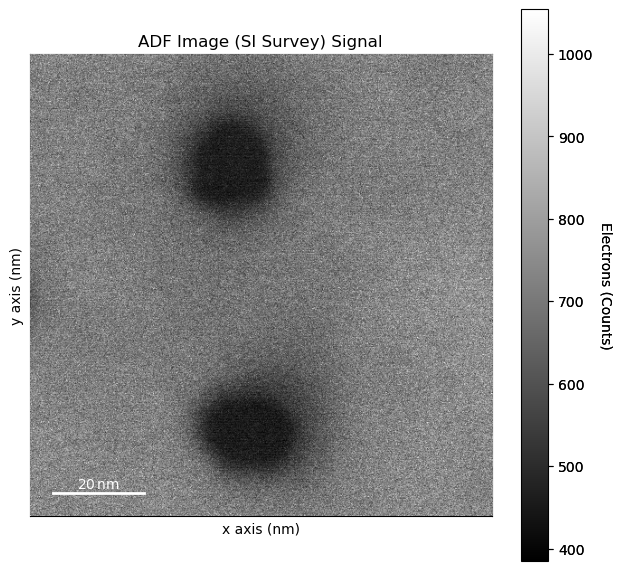

In [3]:
%matplotlib inline
load("adf_survey").plot()

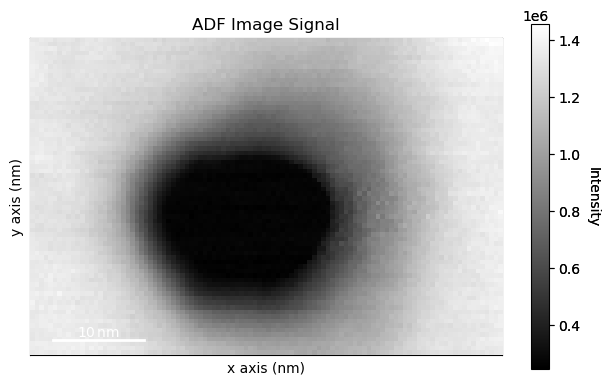

In [4]:
load("adf").plot()

## 3. Declare the elements

`set_elements` states which elements are present, `add_lines` then picks the
matching X-ray lines (K-alpha and so on) for the accelerating voltage of this
measurement.

['N_Ka', 'O_Ka', 'Si_Ka']


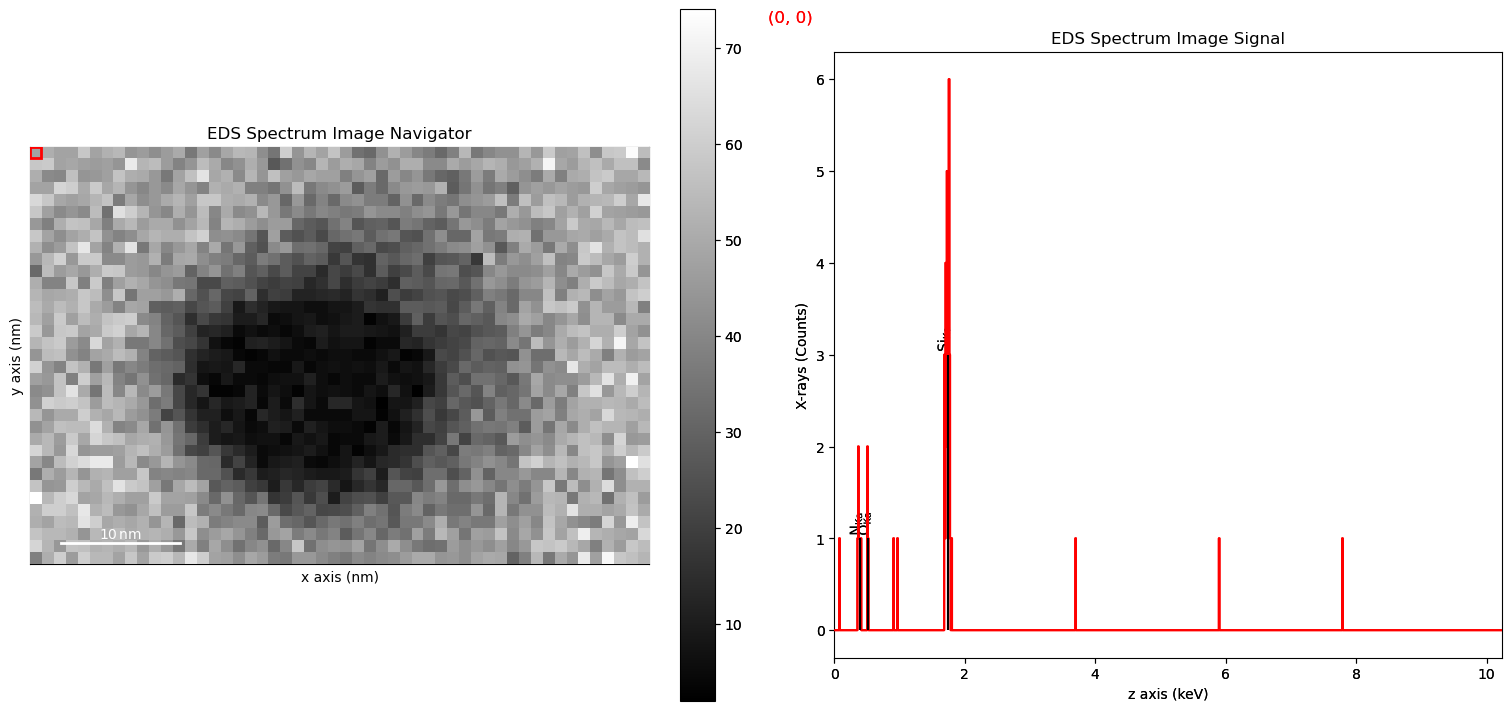

In [5]:
edx_binned = edx.rebin(scale=[2, 2, 1])

edx_binned.set_elements(["Si", "N", "O"])
edx_binned.add_lines()

print(edx_binned.metadata.Sample.xray_lines)
edx_binned.plot(True)  # True = draw the line markers

## 4. Model fitting

Start with the **sum spectrum** (all pixels added up): low noise, fast, and a
good way to check that the line selection is right.

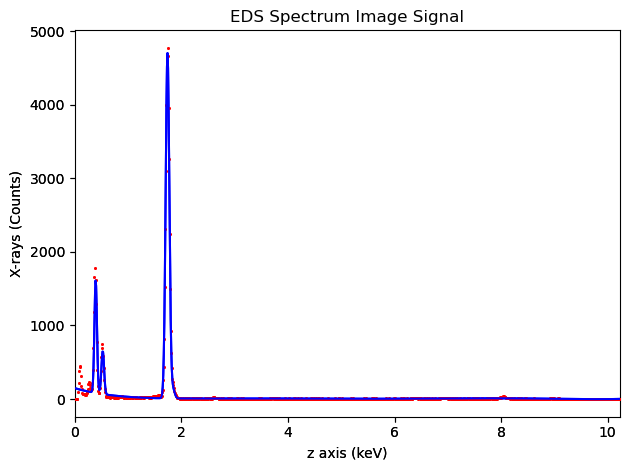

In [6]:
edx_sum = edx_binned.sum()

m_summed = edx_sum.create_model()
m_summed.fit_background()
m_summed.fit()
m_summed.plot()

Now every pixel on its own.

**Note:** the original notebook had `m.fit()` here, which only fits the
*currently selected* pixel - `plot_results()` would then have shown starting
values almost everywhere instead of fit results. `multifit()` covers all
pixels, and takes correspondingly longer.

In [7]:

m = edx_binned.create_model()
m.fit_background()
m.multifit()

100%|██████████| 1820/1820 [00:10<00:00, 167.30it/s]


In [10]:
%matplotlib qt
m.plot()

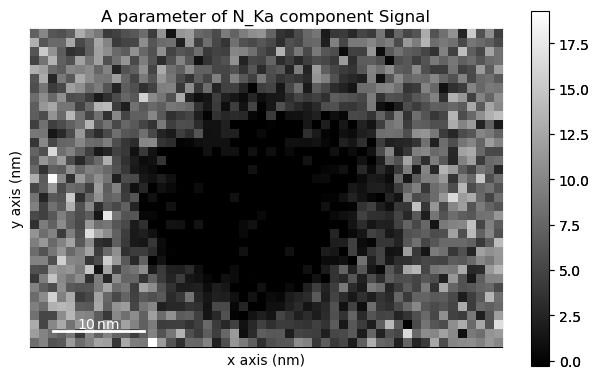

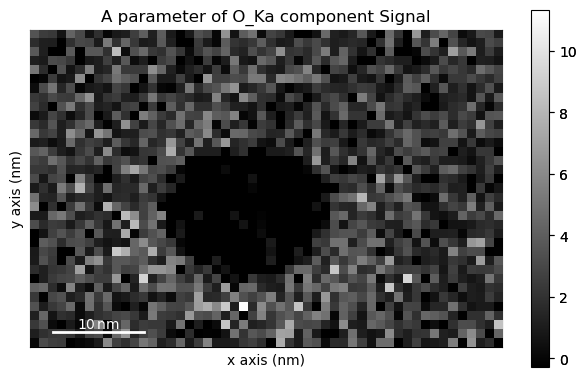

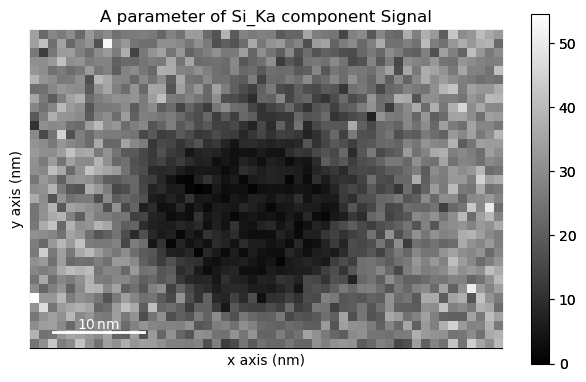

In [9]:
%matplotlib inline
m.plot_results()

## 5. The other route: background windows

Instead of modelling, you can integrate the line directly and subtract a
background estimated from one window on each side of it. Faster and more
intuitive, but sensitive to overlapping lines.

`estimate_background_windows` proposes the windows automatically.

In [13]:
bw = edx_sum.estimate_background_windows(line_width=[5.0, 2.0])

print("One row per line: [left_from, left_to, right_from, right_to] in keV")
print(bw)
%matplotlib qt
edx_sum.plot(background_windows=bw)

One row per line: [left_from, left_to, right_from, right_to] in keV
[[0.05649376 0.11247814 0.642637   0.70150549]
 [0.05649376 0.11247814 0.642637   0.70150549]
 [1.25587152 1.3365096  1.90097616 1.98161424]]


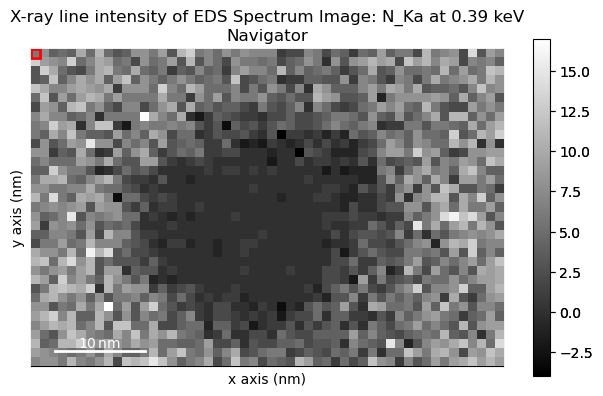

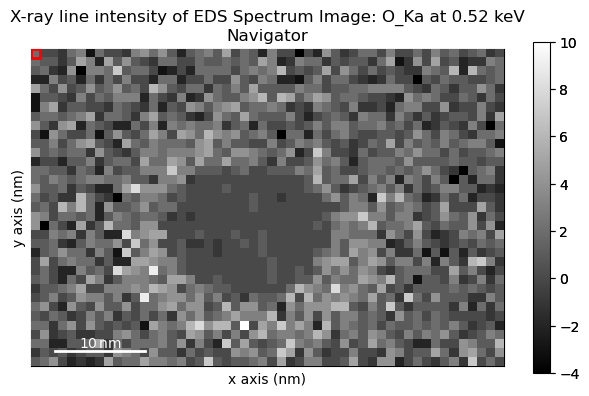

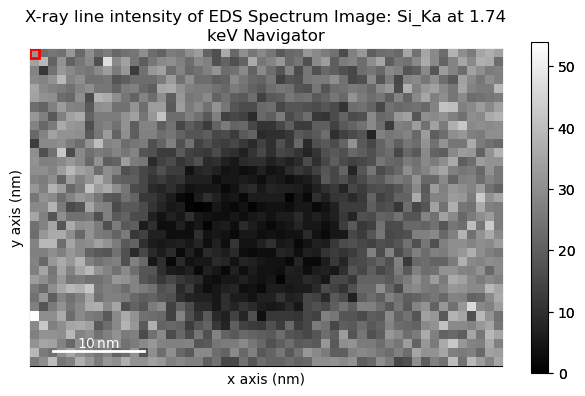

In [15]:
%matplotlib inline
intensities = edx_binned.get_lines_intensity(background_windows=bw, plot_result=True)

## Exercise: set the windows by hand

The automatic estimate is only a proposal. Look closely at the plot above - if
a window sits on a neighbouring line or on a flank, the background is estimated
wrongly and the intensity comes out wrong.

The estimated values are below as a starting point. Change the numbers, run the
cell, look at the plot - then compare the resulting intensity maps with the
ones above.

Row order matches `edx_binned.metadata.Sample.xray_lines`.

In [ ]:
print("Row order:", edx_binned.metadata.Sample.xray_lines)

bw_manual = bw.copy()

# Adjust by hand here, for example:
# bw_manual[0] = [1.55, 1.63, 1.83, 1.91]   # [left_from, left_to, right_from, right_to]

edx_sum.plot(background_windows=bw_manual)

In [ ]:
intensities_manual = edx_binned.get_lines_intensity(
    background_windows=bw_manual, plot_result=True
)

## Exercises

1. For one line, compare the intensity from the model fit (section 4) with the
   one from the background windows (section 5). Where does the difference come from?
2. Change `line_width=[5.0, 2.0]` to `[10.0, 5.0]`. What happens to the windows,
   and why is that dangerous when lines sit close together?
3. The sample is a Si-N membrane. Do the measured intensity ratios match what you
   would expect? What is still missing for a proper quantification?